In [1]:
!pip install jieba

In [2]:
import pandas as pd
import re
import jieba
from collections import Counter

In [3]:
# 读取原始csv（无列名）
df = pd.read_csv("firework_base_corpus.csv", header=None)
df.columns = ["review_text"]

# 去空值
df = df.dropna(subset=["review_text"])
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip() != ""]

# 保存
df.to_csv("clean_base_corpus.csv", index=False, encoding="utf-8-sig")

print("评论数量：", len(df))
df.head()

评论数量： 892


,review_text
0,供肉身以栖居兮，锁游魂于妻怀。\n夫妻永结同心兮，重叙天伦之乐！\n1.一部国产2D RPG...
1,微恐，好玩。解密很简单，剧情很丰富。游戏内还有一些疑团没解开，可能是留下悬念让那个玩家自行脑...
2,还不错，有点惊悚，可玩性比黑森町略逊一筹（美术很好）
3,当初觉得画风有点治愈，然后又是一点中国式恐怖所以买了。其实并不是虚幻真实的可怕，类似于主人公...
4,中式微恐，场景音效做的都非常到位。唯一让我感到惊吓的就是警车撞过来的一瞬间。解密之间过度很不...


In [4]:
def clean_text(text):
    text = str(text)
    text = text.lower()                    # 英文小写
    text = re.sub(r'\d+', '', text)       # 去数字
    text = re.sub(r'[^\w\s\u4e00-\u9fff]', '', text)  # 去标点
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["review_text"].apply(clean_text)

# 保存为txt
with open("corpus_clean_text.txt", "w", encoding="utf-8") as f:
    for line in df["clean_text"]:
        f.write(line + "\n")

df[["review_text", "clean_text"]].head()

,review_text,clean_text
0,供肉身以栖居兮，锁游魂于妻怀。\n夫妻永结同心兮，重叙天伦之乐！\n1.一部国产2D RPG...,供肉身以栖居兮锁游魂于妻怀 夫妻永结同心兮重叙天伦之乐 一部国产d rpg解谜微恐游戏灵异氛...
1,微恐，好玩。解密很简单，剧情很丰富。游戏内还有一些疑团没解开，可能是留下悬念让那个玩家自行脑...,微恐好玩解密很简单剧情很丰富游戏内还有一些疑团没解开可能是留下悬念让那个玩家自行脑补欧亨利式...
2,还不错，有点惊悚，可玩性比黑森町略逊一筹（美术很好）,还不错有点惊悚可玩性比黑森町略逊一筹美术很好
3,当初觉得画风有点治愈，然后又是一点中国式恐怖所以买了。其实并不是虚幻真实的可怕，类似于主人公...,当初觉得画风有点治愈然后又是一点中国式恐怖所以买了其实并不是虚幻真实的可怕类似于主人公的通灵...
4,中式微恐，场景音效做的都非常到位。唯一让我感到惊吓的就是警车撞过来的一瞬间。解密之间过度很不...,中式微恐场景音效做的都非常到位唯一让我感到惊吓的就是警车撞过来的一瞬间解密之间过度很不错故事...


In [5]:
# Step 3: 第一次分词 + 初始词频

with open("corpus_clean_text.txt", "r", encoding="utf-8") as f:
    text = f.read()

tokens = jieba.lcut(text)

# 去掉空词、空格、纯空白token
tokens = [t.strip() for t in tokens if t.strip()]

counter = Counter(tokens)
word_freq = pd.DataFrame(counter.most_common(), columns=["word", "count"])

word_freq.to_csv("word_freq_raw.csv", index=False, encoding="utf-8-sig")

print("Raw word frequency saved as word_freq_raw.csv")
print(word_freq.head(20))


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Syan\AppData\Local\Temp\jieba.cache
Loading model cost 0.562 seconds.
Prefix dict has been built successfully.


Raw word frequency saved as word_freq_raw.csv
   word  count
0     的   7159
1     了   1507
2     是   1391
3     我   1291
4     在   1177
5    游戏   1124
6     也    752
7     人    639
8    恐怖    570
9     和    522
10    很    510
11    都    506
12    有    488
13   一个    453
14   剧情    416
15   故事    416
16   烟火    414
17    中    409
18  陈老师    380
19    让    352


In [7]:
import jieba
from collections import Counter
import pandas as pd

# 读取停用词
with open("cn_stopwords_final.txt", "r", encoding="utf-8") as f:
    stopwords = set(line.strip() for line in f if line.strip())

print("停用词数量：", len(stopwords))


停用词数量： 765


In [8]:
# 读取清洗后的语料
with open("corpus_clean_text.txt", "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f if line.strip()]

print("文本数量：", len(texts))

# 第二次分词 + 去停用词
tokenized_texts = []
all_tokens = []

for text in texts:
    words = jieba.lcut(text)
    
    # 去停用词 + 去单字（可选）
    filtered = [
        w for w in words
        if w not in stopwords and len(w.strip()) > 1
    ]
    
    tokenized_texts.append(filtered)
    all_tokens.extend(filtered)

print("总词数：", len(all_tokens))


文本数量： 891
总词数： 41376


In [12]:
# 统计词频
word_freq = Counter(all_tokens)

# 转为DataFrame
df_freq = pd.DataFrame(word_freq.items(), columns=["word", "count"])

# 按频率排序
df_freq = df_freq.sort_values(by="count", ascending=False)

# 保存
df_freq.to_csv("word_freq_final.csv", index=False, encoding="utf-8-sig")

print("已生成 word_freq_final.csv")
df_freq.head(20)


已生成 word_freq_final.csv


,word,count
52,恐怖,570
541,烟火,414
296,陈老师,380
259,最后,246
677,赵小娟,180
56,希望,167
299,孩子,161
285,天空,135
34,中式,131
309,封建迷信,129


In [16]:
from collections import Counter

bigram_counter = Counter()

for tokens in tokenized_texts:
    for i in range(len(tokens) - 1):
        bigram = tokens[i] + "_" + tokens[i+1]
        bigram_counter[bigram] += 1

print("Bigram数量：", len(bigram_counter))


Bigram数量： 34485


In [19]:
# 转为DataFrame
df_bigram = pd.DataFrame(bigram_counter.items(), columns=["bigram", "count"])

# 排序
df_bigram = df_bigram.sort_values(by="count", ascending=False)

# 保存
df_bigram.to_csv("bigram_freq.csv", index=False, encoding="utf-8-sig")

print("已生成 bigram_freq.csv")
df_bigram.head(20)


已生成 bigram_freq.csv


,bigram,count
535,中式_恐怖,103
325,尸体_腐烂,96
326,腐烂_泥土,95
329,鸟儿_天空,89
836,泥土_我会,76
837,我会_鸟儿,73
999,长亭_古道,47
5130,陈老师_陈老师,41
1709,绽放_烟火,33
24505,陈老师_tt,32


In [21]:
!pip install wordcloud matplotlib jieba


In [22]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [23]:
# 读取最终词频
df = pd.read_csv("word_freq_final.csv", encoding="utf-8-sig")

# 查看前几行
df.head()


,word,count
0,恐怖,570
1,烟火,414
2,陈老师,380
3,最后,246
4,赵小娟,180


In [24]:
# WordCloud 接受 {词: 频率} 的字典
word_freq_dict = dict(zip(df['word'], df['count']))


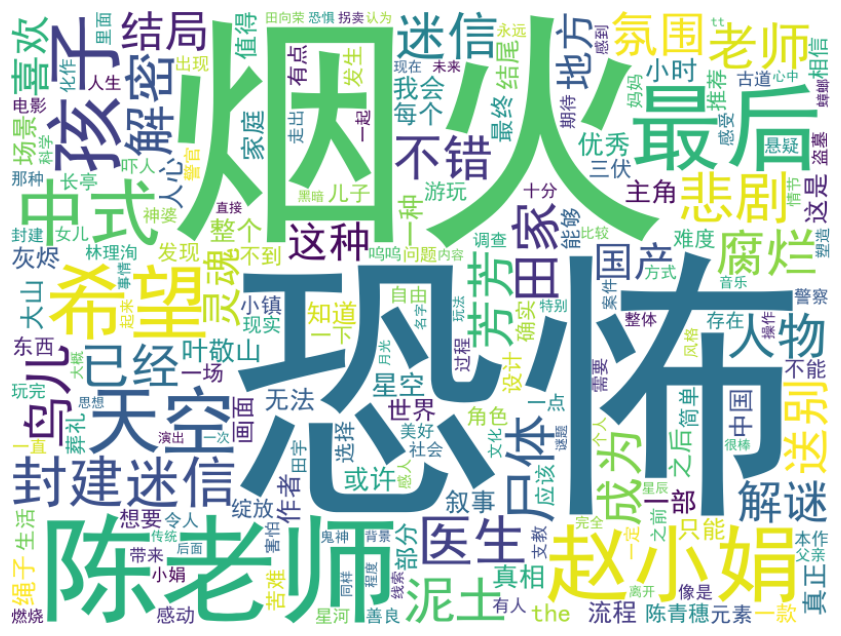

In [25]:
wc = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",  # 请根据你的系统路径修改
    width=800,
    height=600,
    background_color="white",
    max_words=200,       # 词云显示的最大词数
    colormap="viridis"   # 配色方案，可改为 'plasma', 'coolwarm', 'tab20', etc.
)

# 生成词云
wc.generate_from_frequencies(word_freq_dict)

# 显示词云
plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


To avoid semantic overlap in translation, certain Chinese terms with similar meanings were deliberately differentiated (e.g., “结局” as “ending” and “结尾” as “conclusion”). This ensured that distinct narrative concepts remained visible in the visualization.

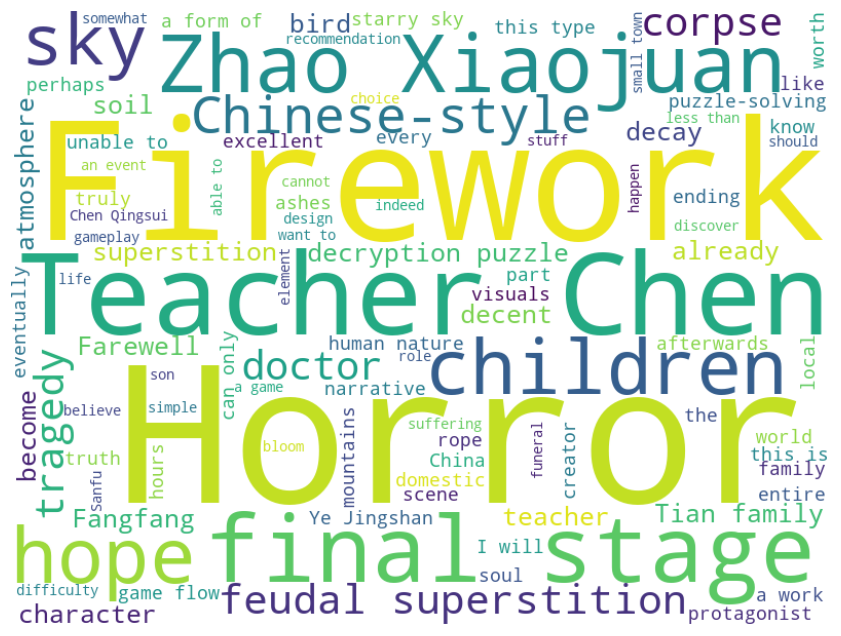

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 读取英文词频表
df_en = pd.read_excel("highfreq_translation.xlsx")

# 构建词频字典（translation -> count）
word_freq_en = dict(zip(df_en["translation"], df_en["count"]))

# 生成词云（英文不需要中文字体）
wc_en = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
)

# 生成词云
wc_en.generate_from_frequencies(word_freq_en)

# 显示词云
plt.figure(figsize=(12,8))
plt.imshow(wc_en, interpolation="bilinear")
plt.axis("off")
plt.show()

An English word cloud was generated using translated high-frequency terms without additional filtering, in order to maintain consistency with the original Chinese frequency distribution.